# Transfer Learning and Distillation Experiments

This notebook implements DenseNet121 feature extraction and knowledge distillation using the tuned baseline architecture as the student.


In [1]:
import os
import json
import random
import pathlib
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras
from keras import layers

from tensorflow.keras.models import load_model

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split

keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)


TensorFlow: 2.21.0
Keras: 3.13.2


In [2]:
USE_COLAB = False  # Set to False to run locally

In [3]:
# Configuration
if USE_COLAB:
    from google.colab import drive

    drive.mount('/content/drive')
    DATASET_ROOT = "/content/drive/MyDrive/x-ray-dataset/"
    SAVE_DIR = pathlib.Path("/content/drive/MyDrive/saved_models")
else:
    DATASET_ROOT = "dataset"
    SAVE_DIR = pathlib.Path("saved_models")

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR = os.path.join(DATASET_ROOT, "val")  # merged into training pool if present
TEST_DIR = os.path.join(DATASET_ROOT, "test")

IMG_SIZE = (150, 150)
BATCH_SIZE = 32
EPOCHS = 20
VAL_SPLIT = 0.1
AUTOTUNE = tf.data.AUTOTUNE

for split_path in [TRAIN_DIR, TEST_DIR]:
    if not os.path.isdir(split_path):
        raise FileNotFoundError(f"Missing directory: {split_path}")

SAVE_DIR.mkdir(parents=True, exist_ok=True)

TEACHER_CHECKPOINT_PATH = SAVE_DIR / "densenet121_frozen_best_checkpoint.keras"
STUDENT_CHECKPOINT_PATH = SAVE_DIR / "baseline_cnn_distilled_best_checkpoint.keras"
STUDENT_BASE_PATH = SAVE_DIR / "baseline_cnn_tuned.keras"

print(f"Environment: {'Google Colab' if USE_COLAB else 'Local'}")
print(f"Dataset root: {DATASET_ROOT}")
print(f"Model artifacts will be stored in: {SAVE_DIR}")


Environment: Local
Dataset root: dataset
Model artifacts will be stored in: saved_models


In [4]:
def _to_serializable(value):
    if isinstance(value, (np.floating, np.integer)):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    return value

def save_model_with_meta(model, name, metrics_dict, history, hyperparams, threshold):
    model_path = SAVE_DIR / f"{name}.keras"
    meta_path = SAVE_DIR / f"{name}_meta.json"
    model.save(model_path)
    history_dict = history.history if hasattr(history, "history") else {}
    metadata = {
        "model_name": name,
        "saved_at": datetime.utcnow().isoformat() + "Z",
        "model_path": str(model_path),
        "threshold": float(threshold),
        "metrics": {k: _to_serializable(v) for k, v in metrics_dict.items()},
        "hyperparameters": {k: _to_serializable(v) for k, v in hyperparams.items()},
        "history": {k: [_to_serializable(x) for x in vals] for k, vals in history_dict.items()},
        "model_params": {
            "total": int(model.count_params()),
            "trainable": int(np.sum([np.prod(v.shape) for v in model.trainable_weights])),
            "non_trainable": int(np.sum([np.prod(v.shape) for v in model.non_trainable_weights])),
        },
    }
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)
    print(f"Saved model to: {model_path}")
    print(f"Saved metadata to: {meta_path}")


In [5]:
# Stratified split + balanced on-the-fly sampling setup
train_root = pathlib.Path(TRAIN_DIR)
val_root = pathlib.Path(VAL_DIR)
all_paths, all_labels = [], []
for source_dir in [train_root, val_root]:
    if not source_dir.is_dir():
        continue
    for class_idx, class_name in enumerate(["NORMAL", "PNEUMONIA"]):
        class_dir = source_dir / class_name
        if not class_dir.is_dir():
            continue
        for img_path in sorted(class_dir.iterdir()):
            if img_path.is_file():
                all_paths.append(str(img_path))
                all_labels.append(class_idx)

all_paths = np.array(all_paths)
all_labels = np.array(all_labels)
train_paths, val_paths, train_labels_raw, val_labels_arr = train_test_split(
    all_paths, all_labels, test_size=VAL_SPLIT, stratify=all_labels, random_state=42,
)

normal_mask = train_labels_raw == 0
pneumonia_mask = train_labels_raw == 1
normal_count = int(normal_mask.sum())
pneumonia_count = int(pneumonia_mask.sum())

if normal_count == 0 or pneumonia_count == 0:
    raise ValueError("Both NORMAL and PNEUMONIA classes must exist in the train split.")

# Infinite balanced datasets need explicit epoch boundaries.
steps_per_epoch = max(1, (2 * pneumonia_count) // BATCH_SIZE)

# Backward-compatible diagnostic variable: represents a 1:1 sampled label set for one epoch.
train_labels_arr = np.concatenate([
    np.zeros(pneumonia_count, dtype=np.int32),
    np.ones(pneumonia_count, dtype=np.int32),
])

print(f"Source pool size (train + optional original val): {len(all_paths)} images")
print(f"Train before balancing -> NORMAL={normal_count}, PNEUMONIA={pneumonia_count}")
print(f"Validation -> NORMAL={(val_labels_arr==0).sum()}, PNEUMONIA={(val_labels_arr==1).sum()}")
print("Balanced sampling strategy -> sample_from_datasets weights [0.5, 0.5]")
print(f"Steps per epoch: {steps_per_epoch}")


Source pool size (train + optional original val): 5232 images
Train before balancing -> NORMAL=1214, PNEUMONIA=3494
Validation -> NORMAL=135, PNEUMONIA=389
Balanced sampling strategy -> sample_from_datasets weights [0.5, 0.5]
Steps per epoch: 218


In [6]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.10),
], name="data_augmentation")

def _load_image(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_jpeg(raw, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img, tf.expand_dims(tf.cast(label, tf.float32), axis=0)

def _load_image_densenet(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_jpeg(raw, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = keras.applications.densenet.preprocess_input(img)
    return img, tf.expand_dims(tf.cast(label, tf.float32), axis=0)

normal_ds = (
    tf.data.Dataset.from_tensor_slices((train_paths[normal_mask], train_labels_raw[normal_mask].astype("float32")))
    .shuffle(normal_count, seed=42, reshuffle_each_iteration=True)
    .repeat()
    .map(_load_image, num_parallel_calls=AUTOTUNE)
)
pneumonia_ds = (
    tf.data.Dataset.from_tensor_slices((train_paths[pneumonia_mask], train_labels_raw[pneumonia_mask].astype("float32")))
    .shuffle(pneumonia_count, seed=42, reshuffle_each_iteration=True)
    .repeat()
    .map(_load_image, num_parallel_calls=AUTOTUNE)
)

train_ds = (
    tf.data.Dataset.sample_from_datasets(
        [normal_ds, pneumonia_ds],
        weights=[0.5, 0.5],
        seed=42,
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
val_ds = (
    tf.data.Dataset.from_tensor_slices((val_paths, val_labels_arr.astype("float32")))
    .map(_load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .cache().prefetch(AUTOTUNE)
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=["NORMAL", "PNEUMONIA"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
).cache().prefetch(AUTOTUNE)

normal_ds_densenet = (
    tf.data.Dataset.from_tensor_slices((train_paths[normal_mask], train_labels_raw[normal_mask].astype("float32")))
    .shuffle(normal_count, seed=42, reshuffle_each_iteration=True)
    .repeat()
    .map(_load_image_densenet, num_parallel_calls=AUTOTUNE)
)
pneumonia_ds_densenet = (
    tf.data.Dataset.from_tensor_slices((train_paths[pneumonia_mask], train_labels_raw[pneumonia_mask].astype("float32")))
    .shuffle(pneumonia_count, seed=42, reshuffle_each_iteration=True)
    .repeat()
    .map(_load_image_densenet, num_parallel_calls=AUTOTUNE)
)

train_ds_densenet = (
    tf.data.Dataset.sample_from_datasets(
        [normal_ds_densenet, pneumonia_ds_densenet],
        weights=[0.5, 0.5],
        seed=42,
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
val_ds_densenet = (
    tf.data.Dataset.from_tensor_slices((val_paths, val_labels_arr.astype("float32")))
    .map(_load_image_densenet, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .cache().prefetch(AUTOTUNE)
)

test_paths = []
test_labels = []
for class_idx, class_name in enumerate(["NORMAL", "PNEUMONIA"]):
    class_dir = pathlib.Path(TEST_DIR) / class_name
    for img_path in sorted(class_dir.iterdir()):
        if img_path.is_file():
            test_paths.append(str(img_path))
            test_labels.append(class_idx)

test_ds_densenet = (
    tf.data.Dataset.from_tensor_slices((np.array(test_paths), np.array(test_labels).astype("float32")))
    .map(_load_image_densenet, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .cache().prefetch(AUTOTUNE)
)
print("Datasets are ready.")


Found 624 files belonging to 2 classes.
Datasets are ready.


## DenseNet121 Feature Extraction (Frozen Base)


In [7]:
base_model = keras.applications.DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
)
base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_augmentation(inputs)
x = keras.applications.densenet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
teacher_model = keras.Model(inputs, outputs, name="densenet121_frozen")

teacher_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc"), keras.metrics.Precision(name="precision"), keras.metrics.Recall(name="recall")],
)

teacher_callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", mode="max", patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_accuracy", mode="max", factor=0.3, patience=3, min_lr=1e-7),
    keras.callbacks.ModelCheckpoint(
        TEACHER_CHECKPOINT_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
    ),
]
teacher_history = teacher_model.fit(
    train_ds_densenet,
    validation_data=val_ds_densenet,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    callbacks=teacher_callbacks,
    verbose=1,
)
print(f"Best teacher checkpoint saved to: {TEACHER_CHECKPOINT_PATH}")

# Threshold tuning and evaluation
val_true_batches, val_prob_batches = [], []
for images, labels in val_ds_densenet:
    probs = teacher_model.predict(images, verbose=0).ravel()
    val_prob_batches.append(probs)
    val_true_batches.append(labels.numpy().ravel())
val_true = np.concatenate(val_true_batches).astype(int)
val_prob = np.concatenate(val_prob_batches)
thresholds = np.linspace(0.05, 0.95, 91)
val_f1_scores = []
for t in thresholds:
    val_pred_t = (val_prob >= t).astype(int)
    report_t = classification_report(val_true, val_pred_t, target_names=["NORMAL", "PNEUMONIA"], output_dict=True, zero_division=0)
    val_f1_scores.append(report_t["PNEUMONIA"]["f1-score"])
teacher_threshold = float(thresholds[int(np.argmax(val_f1_scores))])

y_true_batches, y_prob_batches = [], []
for images, labels in test_ds_densenet:
    probs = teacher_model.predict(images, verbose=0).ravel()
    y_prob_batches.append(probs)
    y_true_batches.append(labels.numpy().ravel())
y_true = np.concatenate(y_true_batches).astype(int)
y_prob = np.concatenate(y_prob_batches)
y_pred = (y_prob >= teacher_threshold).astype(int)
teacher_report = classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"], output_dict=True, zero_division=0)
teacher_metrics = {
    "accuracy": float((y_pred == y_true).mean()),
    "auc": float(roc_auc_score(y_true, y_prob)),
    "precision": float(teacher_report["PNEUMONIA"]["precision"]),
    "recall": float(teacher_report["PNEUMONIA"]["recall"]),
    "f1": float(teacher_report["PNEUMONIA"]["f1-score"]),
}
save_model_with_meta(teacher_model, "densenet121_frozen", teacher_metrics, teacher_history, {"learning_rate":1e-3, "frozen_base": True}, teacher_threshold)
print("DenseNet121 frozen metrics:", teacher_metrics)


Epoch 1/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 215s 941ms/step - accuracy: 0.8972 - auc: 0.9584 - loss: 0.2591 - precision: 0.9044 - recall: 0.8929 - val_accuracy: 0.8702 - val_auc: 0.9588 - val_loss: 0.2724 - val_precision: 0.8673 - val_recall: 0.9743 - learning_rate: 0.0010
Epoch 2/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 106s 488ms/step - accuracy: 0.9163 - auc: 0.9671 - loss: 0.2287 - precision: 0.9211 - recall: 0.9105 - val_accuracy: 0.9122 - val_auc: 0.9608 - val_loss: 0.2250 - val_precision: 0.9478 - val_recall: 0.9332 - learning_rate: 0.0010
Epoch 3/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 234s 1s/step - accuracy: 0.9186 - auc: 0.9697 - loss: 0.2180 - precision: 0.9259 - recall: 0.9105 - val_accuracy: 0.9084 - val_auc: 0.9432 - val_loss: 0.2630 - val_precision: 0.9338 - val_recall: 0.9434 - learning_rate: 0.0010
Epoch 4/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 107s 491ms/step - accuracy: 0.9206 - auc: 0.9731 - loss: 0.2073 - precision: 0.9205 - recall: 0.9184 - val_accuracy: 0.9065 - val_auc: 0.9390 - val_loss:

## Comparison Across All 3 Models


                       Model  Test Acc  Test AUC  Precision    Recall  \
0               Baseline CNN  0.875000  0.951172   0.842105  0.984615   
1    Baseline CNN (tuned HP)  0.703526  0.715034   0.702170  0.912821   
2  DenseNet121 (frozen base)  0.758013  0.812733   0.737575  0.951282   

         F1  Best Threshold  Trainable Params  
0  0.907801            0.80           1207201  
1  0.793757            0.68            813985  
2  0.830907            0.47            263169  


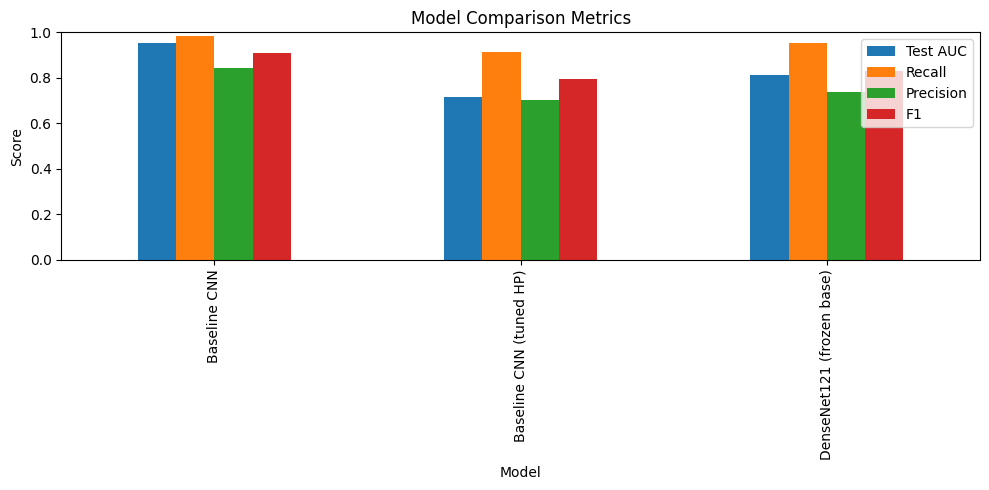

In [8]:
def load_meta(name):
    meta_path = SAVE_DIR / f"{name}_meta.json"
    if not meta_path.exists():
        return None
    with open(meta_path, "r", encoding="utf-8") as f:
        return json.load(f)

records = []
for model_name, label in [
    ("baseline_cnn", "Baseline CNN"),
    ("baseline_cnn_tuned", "Baseline CNN (tuned HP)"),
    ("densenet121_frozen", "DenseNet121 (frozen base)")
]:
    meta = load_meta(model_name)
    if meta is None:
        continue
    m = meta["metrics"]
    records.append({
        "Model": label,
        "Test Acc": m.get("accuracy"),
        "Test AUC": m.get("auc"),
        "Precision": m.get("precision"),
        "Recall": m.get("recall"),
        "F1": m.get("f1"),
        "Best Threshold": meta.get("threshold"),
        "Trainable Params": meta.get("model_params", {}).get("trainable"),
    })

comparison_df = pd.DataFrame(records)
print(comparison_df)

# Bar chart for AUC / recall / precision / F1
if not comparison_df.empty:
    metric_cols = ["Test AUC", "Recall", "Precision", "F1"]
    ax = comparison_df.set_index("Model")[metric_cols].plot(kind="bar", figsize=(10, 5))
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.set_title("Model Comparison Metrics")
    plt.tight_layout()
    plt.show()
